In [13]:
# ============================================================
# LOGISTIC REGRESSION - F1 SCORE AND ROC ANALYSIS
# ============================================================

# Step 1: Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    f1_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report
)



In [14]:
# ============================================================
# Step 2: Load the dataset
# ============================================================

df = pd.read_csv("customers.csv")

print("First 5 rows:")
print(df.head())



First 5 rows:
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669  9656     7561     214              2674   
1        2       3   7057  9810     9568    1762              3293   
2        2       3   6353  8808     7684    2405              3516   
3        1       3  13265  1196     4221    6404               507   
4        2       3  22615  5410     7198    3915              1777   

   Delicatessen  
0          1338  
1          1776  
2          7844  
3          1788  
4          5185  


In [15]:
# ============================================================
# Step 3: Understand the dataset
# ============================================================

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())





Dataset Shape:
(440, 8)

Column Names:
['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicatessen']

Data Types:
Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicatessen        int64
dtype: object

Missing Values:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicatessen        0
dtype: int64

Duplicate Rows:
0


In [17]:
# ============================================================
# Step 4: Check the target variable
# ============================================================

print("\nChannel Value Counts:")
print(df["Channel"].value_counts())

print("\nChannel Percentages:")
print(df["Channel"].value_counts(normalize=True) * 100)





Channel Value Counts:
Channel
1    298
2    142
Name: count, dtype: int64

Channel Percentages:
Channel
1    67.727273
2    32.272727
Name: proportion, dtype: float64


In [18]:
# ============================================================
# Step 5: Extract X and y
# ============================================================

# Channel is our target variable

X = df.drop("Channel", axis=1)

y = df["Channel"]

print("\nX Shape:")
print(X.shape)

print("\ny Shape:")
print(y.shape)





X Shape:
(440, 7)

y Shape:
(440,)


In [19]:
# ============================================================
# Step 6: Convert target Channel into 0 and 1
# ============================================================

# Channel 1 -> 0
# Channel 2 -> 1

y = y.map({1: 0, 2: 1})

print("\nConverted Target Values:")
print(y.value_counts())





Converted Target Values:
Channel
0    298
1    142
Name: count, dtype: int64


In [20]:
# ============================================================
# Step 7: Feature Engineering
# ============================================================

# Region is a categorical variable.
# Convert Region into dummy variables.

X = pd.get_dummies(
    X,
    columns=["Region"],
    drop_first=True
)

print("\nFeatures after encoding:")
print(X.head())

print("\nFeatures after encoding:")
print(X.columns.tolist())





Features after encoding:
   Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicatessen  Region_2  \
0  12669  9656     7561     214              2674          1338     False   
1   7057  9810     9568    1762              3293          1776     False   
2   6353  8808     7684    2405              3516          7844     False   
3  13265  1196     4221    6404               507          1788     False   
4  22615  5410     7198    3915              1777          5185     False   

   Region_3  
0      True  
1      True  
2      True  
3      True  
4      True  

Features after encoding:
['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicatessen', 'Region_2', 'Region_3']


In [21]:
# ============================================================
# Step 8: Check missing values
# ============================================================

print("\nMissing Values after Feature Engineering:")
print(X.isnull().sum())





Missing Values after Feature Engineering:
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicatessen        0
Region_2            0
Region_3            0
dtype: int64


In [22]:
# ============================================================
# Step 9: Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)





Training Data Shape:
(352, 8)

Testing Data Shape:
(88, 8)


In [23]:
# ============================================================
# Step 10: Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# ============================================================
# Step 11: Create Logistic Regression Model
# ============================================================

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)




,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [24]:
# ============================================================
# Step 12: Make Predictions
# ============================================================

# Predicted class

y_pred = model.predict(X_test_scaled)

# Probability of positive class (Channel 2)

y_prob = model.predict_proba(X_test_scaled)[:, 1]




In [25]:
# ============================================================
# Step 13: F1 Score
# ============================================================

f1 = f1_score(y_test, y_pred)

print("\n==============================")
print("F1 SCORE")
print("==============================")

print("F1 Score:", f1)





F1 SCORE
F1 Score: 0.8363636363636363


In [26]:
# ============================================================
# Step 14: Classification Report
# ============================================================

print("\n==============================")
print("CLASSIFICATION REPORT")
print("==============================")

print(classification_report(y_test, y_pred))





CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.93      0.93        60
           1       0.85      0.82      0.84        28

    accuracy                           0.90        88
   macro avg       0.88      0.88      0.88        88
weighted avg       0.90      0.90      0.90        88



In [27]:
# ============================================================
# Step 15: Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\n==============================")
print("CONFUSION MATRIX")
print("==============================")

print(cm)





CONFUSION MATRIX
[[56  4]
 [ 5 23]]


In [28]:
# ============================================================
# Step 16: ROC-AUC Score
# ============================================================

roc_auc = roc_auc_score(y_test, y_prob)

print("\n==============================")
print("ROC-AUC SCORE")
print("==============================")

print("ROC-AUC Score:", roc_auc)





ROC-AUC SCORE
ROC-AUC Score: 0.938095238095238


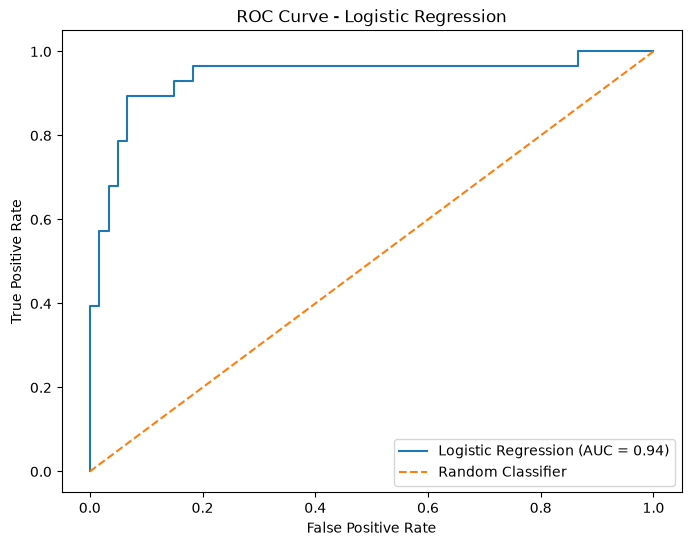

In [29]:
# ============================================================
# Step 17: ROC Curve
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()




In [30]:
# ============================================================
# Step 18: Final Evaluation
# ============================================================

print("\n==============================")
print("FINAL MODEL EVALUATION")
print("==============================")

print("F1 Score      :", f1)

print("ROC-AUC Score :", roc_auc)





FINAL MODEL EVALUATION
F1 Score      : 0.8363636363636363
ROC-AUC Score : 0.938095238095238


In [31]:
# ============================================================
# Step 19: Check Class Imbalance
# ============================================================

class_percentages = (
    y.value_counts(normalize=True) * 100
)

print("\n==============================")
print("CLASS IMBALANCE")
print("==============================")

print(class_percentages)


difference = (
    class_percentages.max()
    - class_percentages.min()
)

if difference > 20:

    print("\nThe dataset has noticeable class imbalance.")

    print(
        "Accuracy alone may not be a reliable evaluation metric."
    )

    print(
        "F1 Score, Precision, Recall and ROC-AUC should also be considered."
    )

else:

    print("\nThe classes are relatively balanced.")


CLASS IMBALANCE
Channel
0    67.727273
1    32.272727
Name: proportion, dtype: float64

The dataset has noticeable class imbalance.
Accuracy alone may not be a reliable evaluation metric.
F1 Score, Precision, Recall and ROC-AUC should also be considered.
